# Exploring the Amazon Fashion metadata

Quick look at the data before building anything. Questions i wanted answered:

1. which fields are actually populated (the pdf lists 14 fields, how many are usable?)
2. does metadata quality depend on popularity (rating count)? this decides how the demo subset gets picked
3. which local embedding model is good enough for conversational queries, and does bm25 add anything
4. what does the LLM planner produce for a few human style queries

Run from the repo root with the raw file in `data/raw/` (`make data`).

In [1]:
import gzip, json, re, itertools, collections, time, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
# work from the repo root whether this runs from notebooks/ or the root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
import os; os.chdir(ROOT); sys.path.insert(0, str(ROOT / "src"))
from stylist.catalog import parse_price, derive_audience, group_key

RAW = Path("data/raw/meta_Amazon_Fashion.jsonl.gz")
assert RAW.exists(), "run `make data` first"
plt.rcParams["figure.dpi"] = 110

## 1. Field coverage

Stream the whole file once (826K rows, about a minute) and count what is non-empty.

In [2]:
keys = collections.Counter(); nonempty = collections.Counter(); n = 0
rating_number = []; title_len = []; dept = collections.Counter(); cat_depth = collections.Counter()
prices = []; years = collections.Counter()
with gzip.open(RAW, "rt") as f:
    for line in f:
        r = json.loads(line); n += 1
        for k, v in r.items():
            keys[k] += 1
            if v not in (None, "", [], {}): nonempty[k] += 1
        rating_number.append(r.get("rating_number") or 0)
        title_len.append(len(r.get("title") or ""))
        cat_depth[len(r.get("categories") or [])] += 1
        d = r.get("details") or {}
        if "Department" in d: dept[d["Department"].strip().lower()] += 1
        p, status = parse_price(r.get("price"))
        if p is not None: prices.append(p)
        m = re.search(r"(\d{4})", d.get("Date First Available", ""))
        if m: years[m.group(1)] += 1
print("rows:", n)
cov = pd.Series({k: nonempty[k] / n for k in keys}).sort_values(ascending=False)
cov.round(3).to_frame("non-empty share")

rows: 826108


,non-empty share
main_category,1.000
average_rating,1.000
rating_number,1.000
parent_asin,1.000
images,1.000
title,1.000
details,0.968
store,0.968
features,0.561
description,0.072


So: `categories` is empty for every single row and `bought_together` is always null. `price` exists for 6%, `description` for 7%. The title is the one field that is always there, and it is dense (brand, gender, product type, colour, size all crammed in). That shaped the whole design: the title carries retrieval, everything else is a bonus.

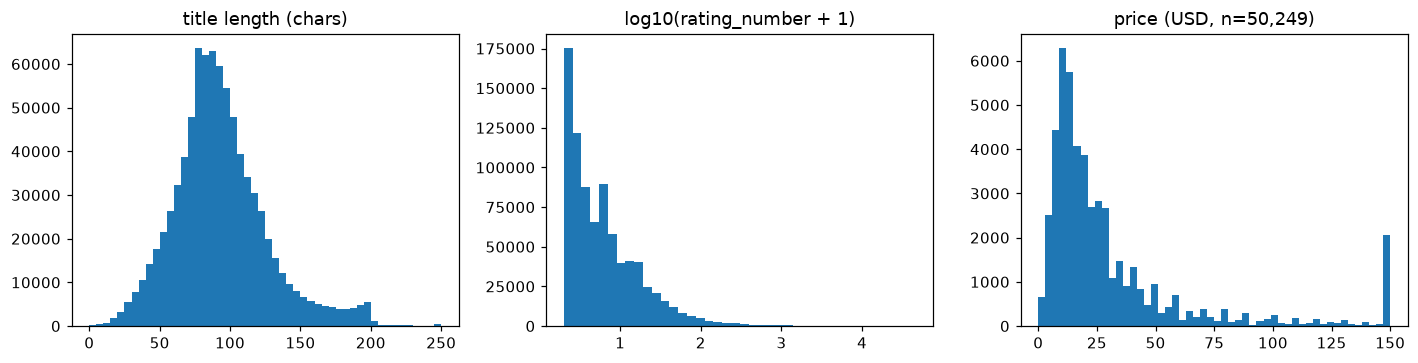

rating_number: median 4.0  >=5: 375906  >=20: 101508  >=100: 16483
price median 19.89 p90 71.91400000000009
categories depth: {0: 826108}
department values (top): [('womens', 52833), ('mens', 19533), ('unisex-adult', 11741), ('girls', 8229), ('boys', 4353), ('unisex-child', 4000), ('women', 3791), ('unisex adult', 2736)]
years listed (top): [('2019', 129790), ('2020', 96249), ('2021', 110445), ('2022', 34350), ('2023', 2686), ('2025', 1), ('2030', 1), ('2099', 1)]


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].hist(np.clip(title_len, 0, 250), bins=50); ax[0].set_title("title length (chars)")
rn = np.array(rating_number); ax[1].hist(np.log10(rn + 1), bins=40); ax[1].set_title("log10(rating_number + 1)")
ax[2].hist(np.clip(prices, 0, 150), bins=50); ax[2].set_title(f"price (USD, n={len(prices):,})")
plt.tight_layout(); plt.show()
print("rating_number: median", np.median(rn), " >=5:", (rn >= 5).sum(), " >=20:", (rn >= 20).sum(), " >=100:", (rn >= 100).sum())
print("price median", np.median(prices), "p90", np.percentile(prices, 90))
print("categories depth:", dict(cat_depth))
print("department values (top):", dept.most_common(8))
print("years listed (top):", sorted(years.items())[-8:])

## 2. Does popularity buy better metadata?

The ingest step records coverage per rating bucket (`data/processed/ingest_stats.json`, written by `make ingest`). This is the evidence behind indexing the most-rated 100K items by default for the demo.

,price,features,description,image_url,department,material,rows
rating_number bucket,,,,,,,
0-4,0.0485,0.5026,0.0617,1.0,0.1168,0.0181,450202.0
5-19,0.0529,0.6051,0.0615,1.0,0.1379,0.0300,274398.0
20-99,0.1127,0.6785,0.1227,1.0,0.2482,0.0575,85025.0
100-inf,0.2638,0.7926,0.2546,1.0,0.4914,0.0867,16483.0


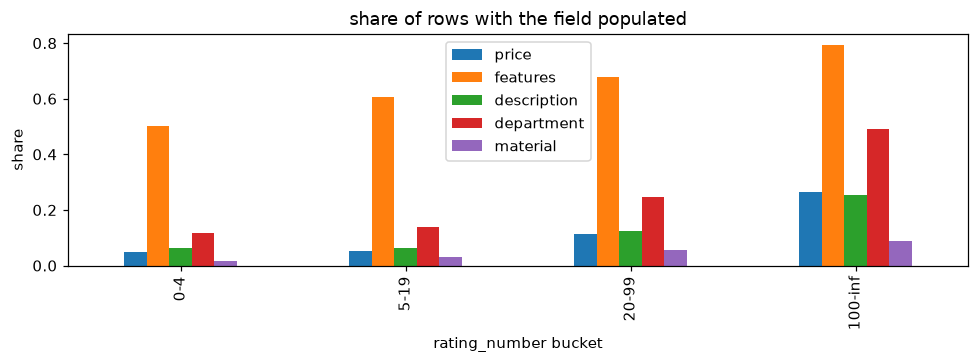

In [4]:
stats = json.loads(Path("data/processed/ingest_stats.json").read_text())
by_bucket = pd.DataFrame(stats["by_rating_bucket"]).T
by_bucket.index.name = "rating_number bucket"
display(by_bucket)
by_bucket.drop(columns=["rows", "image_url"]).plot.bar(figsize=(9, 3.4), title="share of rows with the field populated")
plt.ylabel("share"); plt.tight_layout(); plt.show()

Price coverage goes from 5% (0-4 ratings) to 26% (100+ ratings), features from 50% to 79%, department from 12% to 49%. Images are 100% everywhere. Popular listings are simply better documented, which matters a lot for a demo where the LLM has to explain its picks. The trade-off (long tail products never get indexed) is measured in `docs/evaluation.md` by also running the full catalog.

## 3. Audience heuristic and variant grouping

No taxonomy, so audience is guessed from `details.Department` first and the title second. Variant listings (same product, other size or colour) get a `group_key` so they collapse at query time instead of being deleted at ingest.

In [5]:
sample = []
with gzip.open(RAW, "rt") as f:
    for line in itertools.islice(f, 0, 300000, 12000):
        sample.append(json.loads(line))
rows = [{"audience": derive_audience(r["title"], (r.get("details") or {}).get("Department")),
         "group_key": group_key(r["title"])[:60], "title": r["title"][:70]} for r in sample]
pd.DataFrame(rows).head(25)

,audience,group_key,title
0,men,yuedge 5 pairs men's moisture control cushione...,YUEDGE 5 Pairs Men's Moisture Control Cushione...
1,men,mountain hardwear men's ratio down vest,Mountain Hardwear Men's Ratio Down Vest (Hardw...
2,women,peacameo women's summer casual tank tops scoop...,Peacameo Women's Summer Casual Tank Tops Scoop...
3,women,manzhen gold dolphin whale tail wrap ring mini...,MANZHEN Gold Dolphin Whale Tail Wrap Ring Mini...
4,unisex,dwwq glory to ukraine slava ukraini caps for m...,DWWQ Glory to Ukraine Slava Ukraini caps for M...
5,men,gsg mens rivet leather belts stylish studded b...,GSG Mens Rivet Leather Belts Stylish Studded B...
6,women,timeson tunic tops for leggings for women shor...,Timeson Tunic Tops For Leggings For Women Shor...
7,unknown,selectees wome graphic v-neck t shirts black l...,SELECTEES Wome Graphic V-Neck T Shirts Black L...
8,women,okdeals charm butterfly necklace crystal drop ...,Okdeals Charm Butterfly Necklace Crystal Drop ...
9,women,myhalf tie dye crop top pullover women long sl...,MYHALF Tie Dye Crop Top Pullover Women Long Sl...


## 4. Embedding models vs BM25 on conversational queries

40K listings with at least 5 ratings, 8 queries written the way a person would type them. No labels here, just eyeballing the top 3 per model. The full comparison is slow on CPU, takes ~2 min on an M-series GPU.

In [6]:
from sentence_transformers import SentenceTransformer
import bm25s
from stylist.catalog import build_doc_text

docs, titles = [], []
with gzip.open(RAW, "rt") as f:
    for line in f:
        r = json.loads(line)
        if (r.get("rating_number") or 0) < 5: continue
        docs.append(build_doc_text(r)); titles.append(r["title"][:80])
        if len(docs) >= 40000: break
queries = ["I need an outfit to go to the beach this summer", "warm waterproof boots for hiking in snow",
           "elegant black dress for a wedding guest", "men's slim fit chinos for the office",
           "cozy oversized sweater for fall", "running shoes with good arch support for flat feet",
           "something to keep my ears warm in winter", "comfortable sandals for walking around europe"]

bm = bm25s.BM25(); bm.index(bm25s.tokenize(docs, stopwords="en", show_progress=False), show_progress=False)
results = {"bm25": []}
for q in queries:
    sc = bm.get_scores(bm25s.tokenize([q], stopwords="en", return_ids=False, show_progress=False)[0])
    results["bm25"].append([titles[i] for i in np.argsort(-sc)[:3]])

models = {"bge-small-en-v1.5": ("BAAI/bge-small-en-v1.5", "Represent this sentence for searching relevant passages: "),
          "all-MiniLM-L6-v2": ("sentence-transformers/all-MiniLM-L6-v2", ""),
          "arctic-embed-xs": ("Snowflake/snowflake-arctic-embed-xs", "Represent this sentence for searching relevant passages: ")}
speed = {}
for name, (path, prefix) in models.items():
    m = SentenceTransformer(path)
    t = time.time(); E = m.encode(docs, batch_size=128, normalize_embeddings=True, show_progress_bar=False); speed[name] = len(docs) / (time.time() - t)
    Q = m.encode([prefix + q for q in queries], normalize_embeddings=True)
    S = Q @ E.T
    results[name] = [[titles[i] for i in np.argsort(-S[qi])[:3]] for qi in range(len(queries))]
print({k: f"{v:.0f} docs/s" for k, v in speed.items()})
for qi, q in enumerate(queries):
    print("\n###", q)
    for name in results:
        print(f"  {name:18s}", " | ".join(t[:45] for t in results[name][qi]))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

{'bge-small-en-v1.5': '761 docs/s', 'all-MiniLM-L6-v2': '1411 docs/s', 'arctic-embed-xs': '1458 docs/s'}

### I need an outfit to go to the beach this summer
  bm25               WAYB Crossbody Catchall - Black | Ready to Ro | Kerr's Choice Pink Kitty Bag for Girls | Pink | Toddler Girl Summer Tulle Dress Cotton Casual
  bge-small-en-v1.5  Womens Summer Fashion Beach Boho Loose Fit Ca | Summer Beach Dresses for Women Tshirt Sundres | POPYOUNG Women's 2022 Summer Casual Tshirt Dr
  all-MiniLM-L6-v2   Fashion Bikini Swimwear Swimsuit Dress for Wo | Summer Beach Dresses for Women Tshirt Sundres | Summer Casual Tshirt Dresses for Women Swing 
  arctic-embed-xs    Women Summer Beach Boho Cute Pocket Casual Ts | Summer Beach Maxi Dresses for Women Off The S | POPYOUNG Women's 2023 Summer Casual Tshirt Dr

### warm waterproof boots for hiking in snow
  bm25               Mishansha Women's Duck Boots Cold weather Sli | Mens Insulated Waterproof Hiking Snow Boots W | PENGCHENG Men's Snow Boots 

What i took from this:

* bm25 alone is hopeless for "outfit for the beach" (it matches *outfit* and *summer* in toddler listings) and for "keep my ears warm", but it is great at exact phrases like "wedding guest".
* bge-small gives the most sensible lists of the three and is still ~1100 docs/s on the laptop GPU, so it became the default. arctic-xs is faster and close behind, MiniLM is noticeably weaker.
* gender leaks through on dense only ("men's chinos" returned a women's office suit at rank 3), which is why the service has an audience filter applied as a mask before ranking.

Hence hybrid: dense + bm25 fused with reciprocal rank fusion.

## 5. What the planner does with human queries

Needs an LLM key in the environment (`LLM_PROVIDER`, see `.env.example`). Skipped otherwise.

In [7]:
from stylist.config import Settings
from stylist.llm import make_llm_client
from stylist.planner import LLMPlanner

settings = Settings.from_env()
llm = make_llm_client(settings)
if llm is None:
    print("no LLM configured, skipping")
else:
    print("model:", llm.model)
    planner = LLMPlanner(llm)
    for q in ["I need an outfit to go to the beach this summer",
              "what should my husband wear to an outdoor wedding in june, budget 200 total",
              "chaussures de running pas cheres pour femme"]:
        plan = await planner.plan(q, timeout=60)
        print("\n###", q)
        print("  intent:", plan.intent, "| audience:", plan.audience, "| budget:", plan.budget_max, plan.budget_scope)
        for s in plan.slots:
            print(f"  - {s.name:14s} q={s.search_query!r}  kw={s.keywords}  budget={s.budget_max}")

model: claude-sonnet-4-6



### I need an outfit to go to the beach this summer
  intent: Complete beach outfit for summer | audience: None | budget: None unknown
  - swimsuit       q="women's summer beach swimsuit one piece or bikini"  kw=['swimsuit', 'bikini', 'one piece', 'swimwear', 'bathing suit']  budget=None
  - cover-up       q="women's beach cover up dress summer lightweight"  kw=['cover up', 'coverup', 'cover-up', 'sarong', 'kaftan']  budget=None
  - sandals        q="women's beach sandals summer flat"  kw=['sandals', 'sandal', 'flip flops', 'slides', 'thongs']  budget=None
  - sun hat        q="women's summer beach sun hat wide brim"  kw=['sun hat', 'beach hat', 'straw hat', 'wide brim hat']  budget=None
  - beach bag      q="women's large beach tote bag summer"  kw=['beach bag', 'tote', 'beach tote', 'straw bag']  budget=None



### what should my husband wear to an outdoor wedding in june, budget 200 total
  intent: Outfit for a man attending an outdoor wedding in June, total budget $200 | audience: men | budget: 200.0 total
  - suit / dress pants q="men's lightweight summer dress trousers wedding"  kw=['dress pants', 'trousers', 'chinos', 'slacks']  budget=54.62
  - dress shirt    q="men's lightweight dress shirt summer wedding"  kw=['dress shirt', 'button down', 'button up', 'oxford shirt']  budget=35.38
  - blazer         q="men's lightweight summer blazer wedding outdoor"  kw=['blazer', 'sport coat', 'suit jacket']  budget=46.92
  - dress shoes    q="men's leather oxford loafer dress shoes wedding"  kw=['oxford', 'loafer', 'derby', 'dress shoes']  budget=43.08
  - tie / pocket square q="men's wedding tie pocket square set summer"  kw=['tie', 'necktie', 'pocket square', 'bow tie']  budget=20.0



### chaussures de running pas cheres pour femme
  intent: Find affordable women's running shoes | audience: women | budget: None unknown
  - running shoes  q="women's running shoes affordable"  kw=['running shoes', 'running sneakers', 'trainers', 'athletic shoes']  budget=None


The planner translates the french query, splits the outfit into pieces and allocates a total budget across slots (shoes get more than the tie). Those per-slot queries are what the retriever actually searches, the shopper's sentence never hits the index directly.